# SAMSum Dataset Exploration

## Objective
This notebook explores the SAMSum dialogue summarization dataset to:

- Understand dataset structure
- Analyze dialogue and summary lengths
- Identify preprocessing requirements
- Determine optimal max input length for T5
- Justify modeling decisions

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_from_disk
import pandas as pd

/Users/snareddy/Desktop/meeting-summarizer/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/snareddy/Desktop/meeting-summarizer/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_from_disk("../data/raw")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 14731
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 818
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 819
    })
})


In [3]:
sample = dataset["train"][0]
sample

{'id': '13818513',
 'dialogue': "Amanda: I baked  cookies. Do you want some?\nJerry: Sure!\nAmanda: I'll bring you tomorrow :-)",
 'summary': 'Amanda baked cookies and will bring Jerry some tomorrow.'}

In [4]:
for split in dataset.keys():
    print(f"{split} size: {len(dataset[split])}")

train size: 14731
validation size: 818
test size: 819


In [5]:
dialogue_lengths = [len(x["dialogue"]) for x in dataset["train"]]
summary_lengths = [len(x["summary"]) for x in dataset["train"]]

print("Dialogue length stats:")
print("Mean:", np.mean(dialogue_lengths))
print("Max:", np.max(dialogue_lengths))
print("Min:", np.min(dialogue_lengths))

print("\nSummary length stats:")
print("Mean:", np.mean(summary_lengths))
print("Max:", np.max(summary_lengths))
print("Min:", np.min(summary_lengths))

Dialogue length stats:
Mean: 502.307922069106
Max: 5474
Min: 29

Summary length stats:
Mean: 110.13902654266512
Max: 300
Min: 3


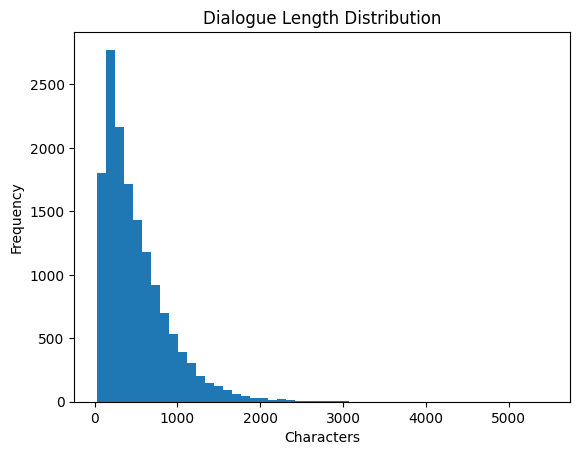

In [6]:
plt.figure()
plt.hist(dialogue_lengths, bins=50)
plt.title("Dialogue Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

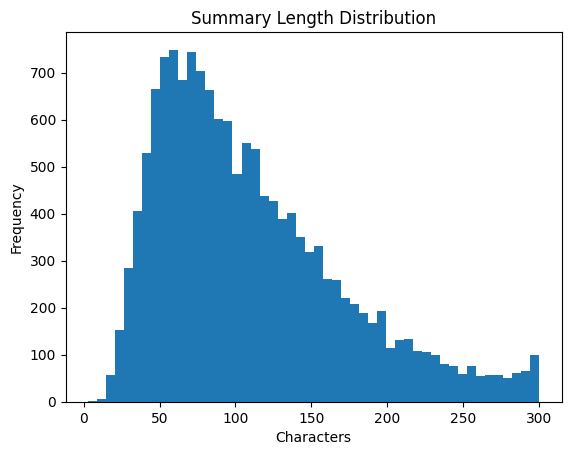

In [7]:
plt.figure()
plt.hist(summary_lengths, bins=50)
plt.title("Summary Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

In [8]:
from transformers import T5Tokenizer

tokenizer = T5Tokenizer.from_pretrained("t5-small")

token_lengths = []

for example in dataset["train"]:
    tokens = tokenizer(example["dialogue"], truncation=False)
    token_lengths.append(len(tokens["input_ids"]))

print("Token length stats:")
print("Mean:", np.mean(token_lengths))
print("Max:", np.max(token_lengths))

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Token indices sequence length is longer than the specified maximum sequence length for this model (567 > 512). Running this sequence through the model will result in indexing errors


Token length stats:
Mean: 148.89763084651415
Max: 1153


In [9]:
exceed_512 = sum(1 for x in token_lengths if x > 512)

print("Number exceeding 512 tokens:", exceed_512)
print("Percentage:", exceed_512 / len(token_lengths) * 100)

Number exceeding 512 tokens: 164
Percentage: 1.113298486185595


Token length analysis showed that only 1.11% of dialogues exceed the 512-token limit of T5-small. Therefore, we adopted a truncation-based strategy with max_input_length=512, ensuring computational efficiency without significant information loss.